# GAT — отчёт по результатам

**Горизонт:** 24 часа  
**Конфигурация:** A — baseline EgoGAT (`--no-adaptive`, без идей из статей)  


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Параметры отчёта
HORIZON = 24
CONFIG_LABEL = "A — baseline EgoGAT (--no-adaptive)"

# Путь к сохранённым результатам обучения (Kaggle), с локальным фолбэком
CANDIDATES = [
    "/kaggle/input/notebooks/raviol/gat-leaning-claude/eda_output",
    "/kaggle/working/eda_output",
    "eda_output",
]
DATA_DIR = next((p for p in CANDIDATES if os.path.isdir(p)), CANDIDATES[0])
print("Читаю результаты из:", DATA_DIR)
print("Файлы:", [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')] if os.path.isdir(DATA_DIR) else "(папка не найдена)")

Читаю результаты из: eda_output
Файлы: ['gat_history_24h.csv', 'gat_summary_24h.csv', 'gat_synth_validation_24h.csv', 'gat_results_24h.csv', 'final_clusters.csv']


In [13]:
def load_csv(name):
    path = os.path.join(DATA_DIR, name)
    return pd.read_csv(path) if os.path.exists(path) else None

summary = load_csv(f"gat_summary_{HORIZON}h.csv")
results = load_csv(f"gat_results_{HORIZON}h.csv")
history = load_csv(f"gat_history_{HORIZON}h.csv")

for name, df in [("summary", summary), ("results", results), ("history", history)]:
    print(f"{name:8s} -> {None if df is None else df.shape}")

summary  -> (1, 10)
results  -> (4474, 15)
history  -> (33, 6)


## 1. Итоговые метрики

In [14]:
if summary is not None:
    display(summary)
else:
    print("Нет gat_summary — считаю сводку из results.")
    if results is not None:
        agg = results.groupby(["horizon", "train_mode", "model"]).agg(
            MAE=("MAE", "mean"), RMSE=("RMSE", "mean"), MAPE=("MAPE", "mean"),
            SMAPE=("SMAPE", "mean"), WAPE=("WAPE", "mean"),
            n_objects=("object_id", "nunique"), n_rows=("MAE", "count"),
        ).round(4).reset_index()
        display(agg)

,horizon,train_mode,model,MAE,RMSE,MAPE,SMAPE,WAPE,n_objects,n_rows
0,24,real_plus_synth,GAT,51.8534,70.0348,97.8665,30.9358,23.7969,1500,4474


In [15]:
# Карточка с ключевыми метриками (среднее по объектам/фолдам)
if results is not None:
    print(f"=== {CONFIG_LABEL} · h={HORIZON} ===")
    for m in ["MAE", "RMSE", "MAPE", "SMAPE", "WAPE"]:
        if m in results:
            print(f"  {m:6s} = {results[m].mean():.4f}")
    print(f"  объектов: {results['object_id'].nunique()} · фолдов: {results['fold'].nunique()} · строк: {len(results)}")

=== A — baseline EgoGAT (--no-adaptive) · h=24 ===
  MAE    = 51.8534
  RMSE   = 70.0348
  MAPE   = 97.8665
  SMAPE  = 30.9358
  WAPE   = 23.7969
  объектов: 1500 · фолдов: 3 · строк: 4474


## 1b. Метрики по «зрелым» (последним) фолдам

Поздние фолды обучены на наибольшей истории → ближе к реальному использованию. Усредняем по последним двум фолдам (`fold >= max_fold − 1`) и группируем по `train_mode` — как в финальном отчёте по TFT. Берёт `gat_results_1h.csv` и `gat_results_24h.csv`, если оба лежат в `DATA_DIR`.

In [16]:
# Метрики по "зрелым" фолдам (последние 2: max_fold и max_fold-1).
# Поздние фолды обучены на бОльшей истории → ближе к боевому прогнозу.
def get_mature_metrics(df, horizon_name):
    max_fold = df["fold"].max()
    mature_df = df[df["fold"] >= max_fold - 1]          # последние 2 фолда
    stats = mature_df.groupby("train_mode").agg(
        MAE=("MAE", "mean"),
        SMAPE=("SMAPE", "mean"),
        WAPE=("WAPE", "mean"),
    ).round(2)
    stats["horizon"] = horizon_name
    return stats.reset_index()

frames = []
for h in [1, 24]:
    path = os.path.join(DATA_DIR, f"gat_results_{h}h.csv")
    if os.path.exists(path):
        frames.append(get_mature_metrics(pd.read_csv(path), f"{h}h"))

if frames:
    final_report = pd.concat(frames)[["horizon", "train_mode", "MAE", "SMAPE", "WAPE"]]
    display(final_report)
else:
    print("Нет gat_results_*.csv в", DATA_DIR)

,horizon,train_mode,MAE,SMAPE,WAPE
0,24h,real_plus_synth,51.18,34.45,26.98


## 2. Кривая обучения (loss по эпохам, по фолдам)

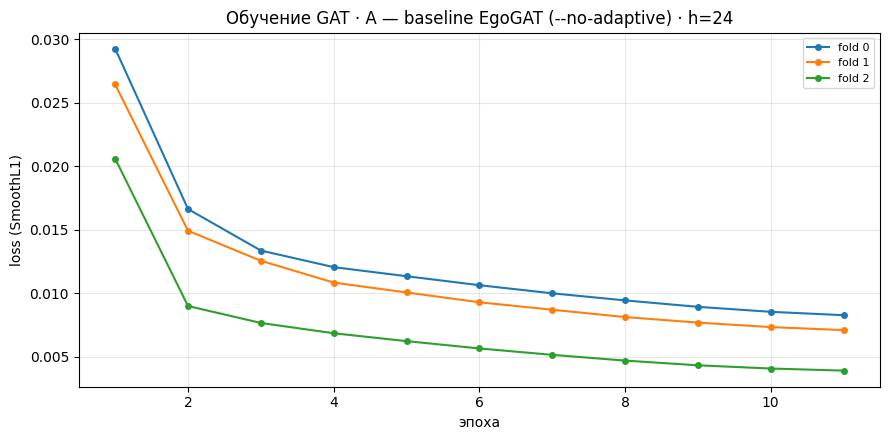

In [17]:
if history is not None and len(history):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    group_cols = [c for c in ["fold", "phase"] if c in history.columns]
    if group_cols:
        for key, g in history.groupby(group_cols):
            label = key if isinstance(key, str) else " · ".join(str(k) for k in np.atleast_1d(key))
            ax.plot(g["epoch"], g["loss"], marker="o", ms=4, label=f"fold {label}")
        ax.legend(fontsize=8)
    else:
        ax.plot(history["epoch"], history["loss"], marker="o", ms=4)
    ax.set_xlabel("эпоха"); ax.set_ylabel("loss (SmoothL1)")
    ax.set_title(f"Обучение GAT · {CONFIG_LABEL} · h={HORIZON}")
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("Нет истории обучения.")

## 3. Метрики по фолдам
Видно, какой фолд труднее (стабильность прогноза во времени).

,MAE,RMSE,MAPE,SMAPE,WAPE
fold,,,,,
0,53.211,73.181,23.475,23.877,17.704
1,64.559,88.549,243.563,37.097,32.323
2,37.912,48.562,27.179,31.826,21.633


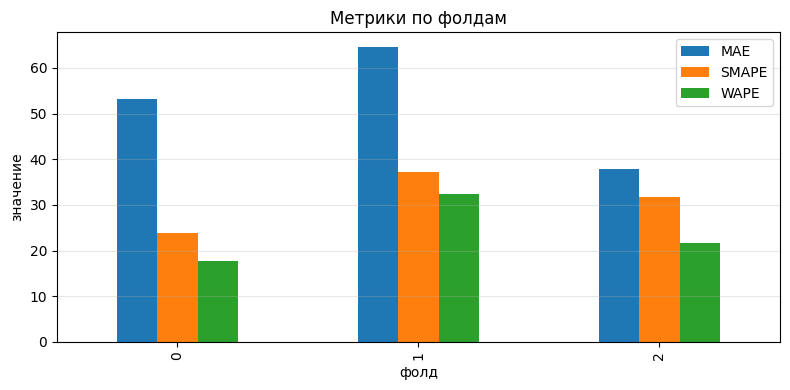

In [18]:
if results is not None:
    by_fold = results.groupby("fold")[["MAE", "RMSE", "MAPE", "SMAPE", "WAPE"]].mean().round(3)
    display(by_fold)
    fig, ax = plt.subplots(figsize=(8, 4))
    by_fold[["MAE", "SMAPE", "WAPE"]].plot(kind="bar", ax=ax)
    ax.set_xlabel("фолд"); ax.set_ylabel("значение")
    ax.set_title("Метрики по фолдам"); ax.grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

## 4. Распределение ошибки по объектам
Среднее vs медиана показывают, тянут ли хвост отдельные тяжёлые объекты.

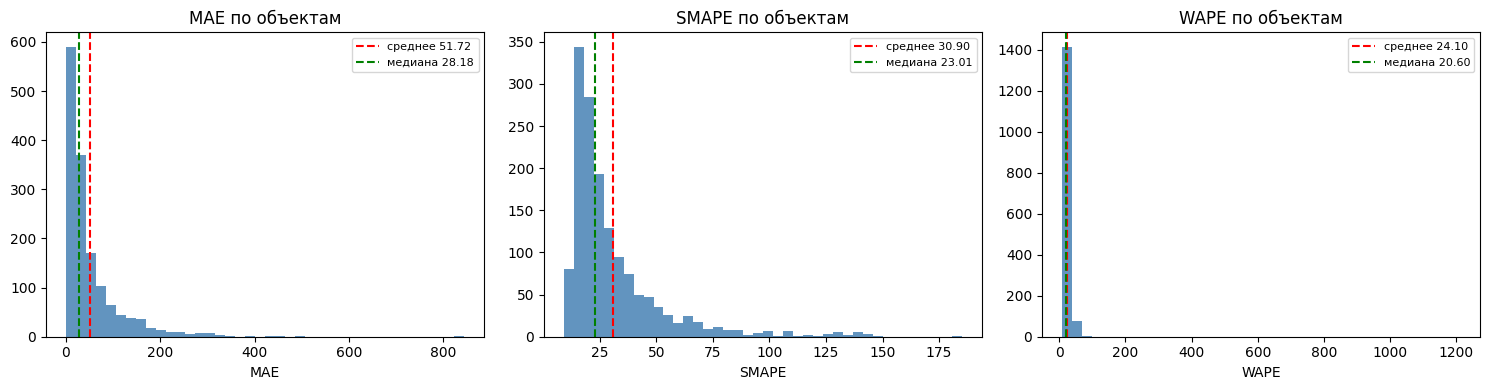

In [19]:
if results is not None:
    per_obj = results.groupby("object_id")[["MAE", "SMAPE", "WAPE", "y_mean"]].mean()
    metrics = ["MAE", "SMAPE", "WAPE"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, m in zip(axes, metrics):
        vals = per_obj[m].dropna()
        ax.hist(vals, bins=40, color="steelblue", alpha=0.85)
        ax.axvline(vals.mean(), color="red", ls="--", label=f"среднее {vals.mean():.2f}")
        ax.axvline(vals.median(), color="green", ls="--", label=f"медиана {vals.median():.2f}")
        ax.set_title(f"{m} по объектам"); ax.set_xlabel(m); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 5. Ошибка vs объём объекта
MAE растёт с объёмом (крупные станции → большие абсолютные ошибки), SMAPE обычно наоборот.

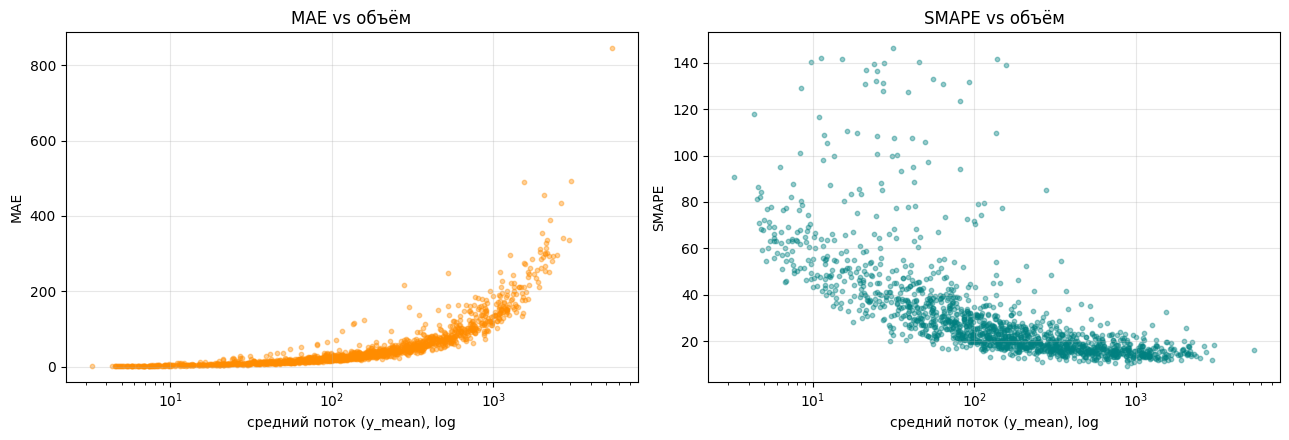

In [20]:
if results is not None and "y_mean" in results.columns:
    agg = results.groupby("object_id").agg(MAE=("MAE", "mean"), SMAPE=("SMAPE", "mean"),
                                           y_mean=("y_mean", "mean"))
    agg = agg[agg["y_mean"] > 0]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].scatter(agg["y_mean"], agg["MAE"], s=10, alpha=0.4, color="darkorange")
    axes[0].set_xscale("log"); axes[0].set_xlabel("средний поток (y_mean), log"); axes[0].set_ylabel("MAE")
    axes[0].set_title("MAE vs объём"); axes[0].grid(alpha=0.3)
    axes[1].scatter(agg["y_mean"], agg["SMAPE"], s=10, alpha=0.4, color="teal")
    axes[1].set_xscale("log"); axes[1].set_xlabel("средний поток (y_mean), log"); axes[1].set_ylabel("SMAPE")
    axes[1].set_title("SMAPE vs объём"); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

## 6. Топ объектов по ошибке

In [21]:
if results is not None:
    per_obj = results.groupby("object_id")[["MAE", "SMAPE", "WAPE", "y_mean"]].mean().round(2)
    print("Худшие 10 объектов по MAE:")
    display(per_obj.sort_values("MAE", ascending=False).head(10))
    print("Лучшие 10 объектов по MAE:")
    display(per_obj.sort_values("MAE").head(10))

Худшие 10 объектов по MAE:


,MAE,SMAPE,WAPE,y_mean
object_id,,,,
RT_7201,844.97,15.99,16.37,5396.50
ST_196,492.04,18.38,17.53,3038.11
ST_1755,489.74,32.51,31.58,1546.85
ST_42,455.10,25.76,22.69,2049.78
ST_244,433.41,17.83,17.04,2640.07
ST_257,390.04,19.78,17.93,2239.72
ST_398,353.91,19.91,17.74,1998.15
ST_152,340.93,15.30,12.94,2706.89
ST_286,335.83,17.82,16.37,2150.31


Лучшие 10 объектов по MAE:


,MAE,SMAPE,WAPE,y_mean
object_id,,,,
RT_2090,0.12,185.19,NaN,0.00
ST_2002089,1.58,69.05,18.78,5.39
RT_3914,1.64,90.96,34.22,3.26
ST_2000104,1.71,81.47,26.72,4.52
ST_2001087,1.72,84.43,31.52,4.76
ST_2000635,1.74,54.68,23.84,5.13
RT_7264,1.76,54.69,25.91,6.83
ST_2001063,1.77,68.19,23.24,4.80
ST_2002980,1.82,71.46,23.64,5.37



## Вывод — A (baseline EgoGAT, `--no-adaptive`), h=24 — по последним 2 фолдам

- **Зрелые метрики (последние 2 фолда): MAE 51.18 · SMAPE 34.45 · WAPE 26.98.**
- Против TFT (49.55 / 31.42 / 23.74): **хуже по всем трём** — MAE **+3%**, SMAPE **+10%**, WAPE **+14%**. На длинном горизонте голый граф-baseline TFT не достаёт.
- Высокие SMAPE/WAPE в зрелом срезе тянет **трудный фолд** (на одном из последних фолдов MAPE 243 — околонулевые потоки раздувают процентную ошибку). При этом MAE всего 51.2 — абсолютная ошибка адекватная, а процентные метрики ловят мелкие объекты.
- Ошибка структурирована по объёму: крупные узлы дают топ MAE (RT_7201 — 845 при потоке 5400), мелкие ряды — копеечный MAE, но огромный SMAPE (50–185%).

**Итог:** на h=24 по последним фолдам baseline **уступает TFT** — это нижняя планка «графа без улучшений». Прирост и стабильность дают именно идеи из статей (D, затем +TimesNet) — их зрелые метрики посчитаем так же, по последним 2 фолдам, когда сравним.

